# SpaceX S-1 — The valuation football field

The DCF put a single number on the equity. But for a company that is ~90% terminal value and tails — a
monopoly cash core, a launch franchise, and a money-losing AI furnace bolted together — *one* lens is the
weakest possible answer. This notebook triangulates the DCF with the methods that **contest** it, and draws
them on one chart as low–high ranges: a **football field**.

The point of a football field is not to manufacture a tidy consensus — it's to make **disagreement**
visible. So every bar here carries information the others don't:

| Method | Engine (independent of?) | What it answers |
|---|---|---|
| **DCF (floored + diluted)** | discounted cash flow (our `dcf.py`) | what the *cash flows* support |
| **SOTP on comps** | peer **market multiples**, by segment | what the *market* pays for each piece |
| **Real-option (AI)** | Bayesian `P × V` on the AI build | what the *option the DCF floors at \$0* is worth |
| **Private mark** | what buyers actually paid (reference line) | what the *market says today* |

> **The one-liner we expect it to make visible:** every method agrees the company is worth ~\$150–240B on
> Starlink + Space + a disciplined read of AI. The rest of the way to the ~\$350B private mark is an **AI
> option** the cash flows don't yet support. The disagreement between methods is, almost entirely, *how you
> value AI*.

**Provenance, loudly.** This is the only notebook that uses **non-S-1 data** (peer multiples, private
marks). Those inputs live in flagged CSVs (`csv/comps.csv`, `csv/market_marks.csv`), are date-stamped, and
are drawn **hatched/outlined** in every chart so you always know what is a filed fact and what is a market
opinion.

## Setup — load the DCF, the comps, and the assembled field

Everything computational lives in `analysis/valuation.py` (which imports `dcf.py` and the segment models),
so this notebook stays a narrated walkthrough. Net debt and the share count are the same S-1 inputs the DCF
uses.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from analysis import charts, dcf, valuation as val

charts.apply_style()
COL = charts.SEGMENT_COLORS
SHARES = val.shares_m()
b2ps = lambda b: b * 1000.0 / SHARES        # equity $B -> $/share (pre-dilution)

A  = dcf.default_assumptions()
ff = val.football_field(A)

print(f"Pro-forma shares: {SHARES:,.0f}M   |   net debt (Mar-2026): ${val.net_debt_m()/1000:.1f}B\n")
disp = ff[["method", "low", "high", "point", "source_flag"]].copy()
disp["$/sh low"]  = b2ps(ff["low"])
disp["$/sh high"] = b2ps(ff["high"])
print("Football field — implied group equity ($B) and per share:")
print(disp.round(2).to_string(index=False))

Pro-forma shares: 12,520M   |   net debt (Mar-2026): $14.4B

Football field — implied group equity ($B) and per share:
                 method    low   high  point source_flag  $/sh low  $/sh high
DCF (floored + diluted)  54.77 224.45 144.11          s1      4.37      17.93
          SOTP on comps 102.60 235.59 169.10    external      8.19      18.82
       Real-option (AI) 159.11 240.61 199.86    external     12.71      19.22
Private mark (Dec-2024) 350.00 350.00 350.00    external     27.95      27.95


## Method 1 — DCF (the bar we're contesting)

The full build is in `notebooks/dcf.ipynb`; here we just lift its output. The DCF bar is the **scenario
range**: from the bear **abandonment floor** (shut the value-destroying AI build, keep Starlink — ≈ standalone
Starlink) up to the bull. The diamond is the **probability-weighted** blend (25/50/25), the single
option-like number that respects the floored downside and the fat-tailed upside.

This is the widest bar on the field, and honestly so: ~90% of a DCF this terminal-heavy is assumption, and
the bear/bull gap *is* the AI keep-vs-abandon decision priced out.

In [2]:
d = val.dcf_range(A)
print("DCF equity, abandonment-floored (SOTP) basis:")
for k in ["bear", "base", "bull"]:
    print(f"  {k.title():4}: ${d[k]/1000:6.1f}B   ({b2ps(d[k]/1000):5.2f}/sh)")
print(f"  prob-weighted (25/50/25): ${d['point']/1000:.1f}B   ({b2ps(d['point']/1000):.2f}/sh)")
print(f"  -> DCF bar: ${d['low']/1000:.0f}-{d['high']/1000:.0f}B")

DCF equity, abandonment-floored (SOTP) basis:
  Bear: $  54.8B   ( 4.37/sh)
  Base: $ 148.6B   (11.87/sh)
  Bull: $ 224.5B   (17.93/sh)
  prob-weighted (25/50/25): $144.1B   (11.51/sh)
  -> DCF bar: $55-224B


## Method 2 — Sum-of-the-parts on peer multiples (external)

A whole-company multiple is meaningless here (what is the "right" EV/EBITDA for a cash cow + a launch
monopoly + a money-losing AI furnace?). So we value each segment on **its own peer set's revenue multiple**
— a market engine genuinely independent of our cash flows — and add them up. Multiples are external
(`csv/comps.csv`, hatched below); the revenue they multiply is the S-1's FY2025 segment revenue.

- **Connectivity / Starlink — 6–10× revenue.** Mature cable/telecom trades ~2.5–4× sales (Charter 2.5×;
  Comcast 4.1× EBITDA); Starlink warrants a large premium for 30%+ growth, 60%+ gross margin, and a global
  near-monopoly — but is capped below pure software.
- **Space — 8–20× *customer* revenue.** Rocket Lab, the only public pure-play, trades ~16–64× revenue; we
  apply a deliberately conservative band. *Understated:* internal Starlink launches are unbooked
  (capitalized into Connectivity), so the launch franchise is bigger than its booked revenue.
- **AI — 5–17× revenue.** Public neoclouds (CoreWeave ~5× forward, Nebius ~17×). Note how *small* this is
  next to the xAI private mark (Method 4) — that gap is the whole argument.

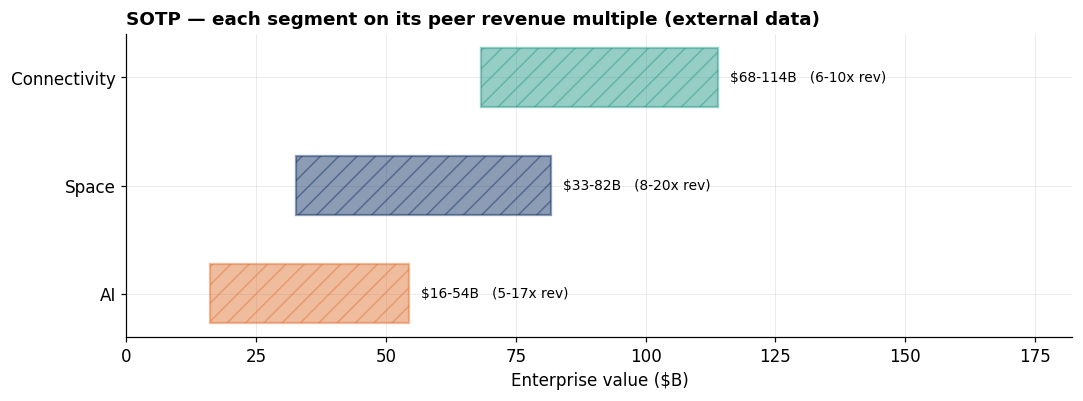

SOTP: EV $117-250B - net debt $14.4B = equity $103-236B ($8.19-18.82/sh)


In [3]:
s = val.sotp_comps()
tbl = s["table"]

fig, ax = plt.subplots(figsize=(10, 3.8))
segs = list(tbl.index); y = np.arange(len(segs))
for i, seg in enumerate(segs):
    lo, hi = tbl.loc[seg, "ev_low"]/1000, tbl.loc[seg, "ev_high"]/1000
    ax.barh(y[i], hi-lo, left=lo, height=0.55, color=COL[seg], alpha=0.5,
            hatch="//", edgecolor=COL[seg], linewidth=1.5, zorder=3)
    ax.annotate(f"${lo:.0f}-{hi:.0f}B   ({tbl.loc[seg,'mult_low']:.0f}-{tbl.loc[seg,'mult_high']:.0f}x rev)",
                (hi, y[i]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(segs); ax.invert_yaxis()
ax.set_xlabel("Enterprise value ($B)")
ax.set_xlim(0, tbl.ev_high.max()/1000 * 1.6)
ax.set_title("SOTP — each segment on its peer revenue multiple (external data)", loc="left", fontsize=12)
charts.finish(fig); charts.save(fig, "val_sotp_segments", layout=False); plt.show()

print(f"SOTP: EV ${s['ev_low']/1000:.0f}-{s['ev_high']/1000:.0f}B "
      f"- net debt ${s['net_debt']/1000:.1f}B = equity "
      f"${s['equity_low']/1000:.0f}-{s['equity_high']/1000:.0f}B "
      f"(${b2ps(s['equity_low']/1000):.2f}-{b2ps(s['equity_high']/1000):.2f}/sh)")

## Method 3 — Real-option on AI: pricing what the DCF floors at \$0

The DCF deliberately floors AI's terminal value at zero (the abandonment option: a fleet that can't cover
its own refresh simply isn't refreshed). That is the right *downside* treatment — but it throws away the
**upside**, which is the entire reason a rational owner keeps funding a −NPV segment. This bar puts that
upside back, as a Bayesian real option, and adds it to the part the DCF values confidently (Starlink + Space).

> **The frame (integrated §7).** With probability `P` the AI build clears its frontier (Grok/leasing
> economics work, the fleet covers refresh + power + R&D) and AI becomes a real franchise worth `payoff`;
> with probability `1 − P` you abandon it — already the DCF's \$0. So the option is worth `P × payoff`. We
> span a **skeptic-to-believer** `P` (15–40%) and a `payoff` from the DCF's own Bull AI *terminal* (~\$70B)
> up to the **standalone xAI private mark (~\$230B, Jan-2026 Series E)**. These are subjective inputs — so
> the bar is shown *wide*, and it is the one most sensitive to assumptions.

Starlink + Space DCF (Base) equity:     $   149B
AI option  P in [15%, 40%] x payoff [$70B, $230B]
  -> AI option value:                   $    10-92B
  -> total equity (Starlink+Space+opt): $   159-241B  ($12.7-19.2/sh)


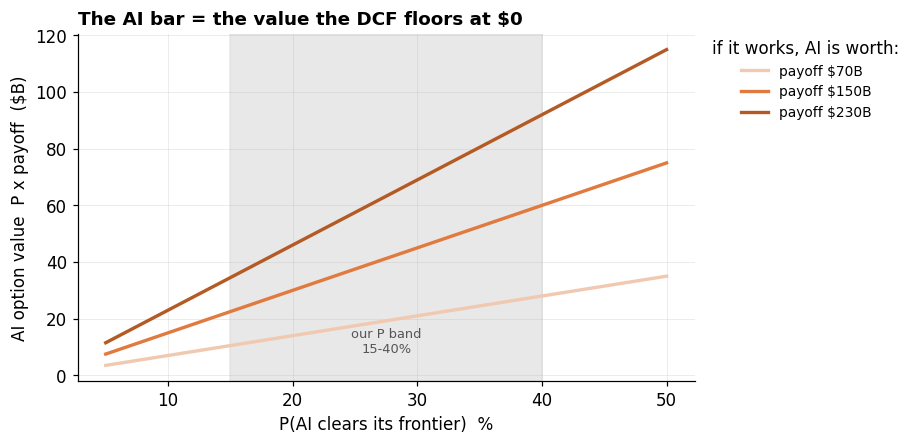

In [4]:
o  = val.AIOptionAssumptions()
ro = val.real_option_ai(A, o)
print(f"Starlink + Space DCF (Base) equity:     ${ro['base_equity']/1000:6.0f}B")
print(f"AI option  P in [{o.p_low:.0%}, {o.p_high:.0%}] x payoff "
      f"[${o.payoff_low_m/1000:.0f}B, ${o.payoff_high_m/1000:.0f}B]")
print(f"  -> AI option value:                   ${ro['ai_option_low']/1000:6.0f}-{ro['ai_option_high']/1000:.0f}B")
print(f"  -> total equity (Starlink+Space+opt): ${ro['low']/1000:6.0f}-{ro['high']/1000:.0f}B  "
      f"(${b2ps(ro['low']/1000):.1f}-{b2ps(ro['high']/1000):.1f}/sh)")

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ps = np.linspace(0.05, 0.50, 60)
for pay, c in [(70, "#f0c9b0"), (150, "#e07a3f"), (230, "#b35a25")]:
    ax.plot(ps*100, ps*pay, color=c, lw=2.2, label=f"payoff ${pay}B")
ax.axvspan(o.p_low*100, o.p_high*100, color="0.85", alpha=0.6, zorder=0)
ax.annotate("our P band\n15-40%", ((o.p_low+o.p_high)/2*100, 8), ha="center", fontsize=8.5, color="#555")
ax.set_xlabel("P(AI clears its frontier)  %"); ax.set_ylabel("AI option value  P x payoff  ($B)")
ax.set_title("The AI bar = the value the DCF floors at $0", loc="left", fontsize=12)
charts.legend_outside(ax, fontsize=9, title="if it works, AI is worth:")
charts.finish(fig); charts.save(fig, "val_ai_option", layout=False); plt.show()

## Method 4 — The private mark (reference line, external)

Not a range — a dated line for "what buyers actually pay." We anchor on the **\$350B Dec-2024 employee
tender**, the conservative, well-established mark the DCF was built against (and, conveniently, ≈ our DCF
**bull**). Later 2025–26 figures (~\$800B tender, a ~\$1.25T SpaceX–xAI merger, a ~\$1.75T IPO target) exist
but are single-source / hype-blog grade — recorded with a `speculative` flag and shown only as a ceiling
annotation, never as the anchor. The **xAI Series E (~\$230B, Jan-2026)** is the solid standalone AI mark,
and it's what makes the real-option bar's upper end defensible.

In [5]:
marks = val.load_marks()
print(marks[["entity", "mark_usd_b", "as_of", "reliability", "note"]].to_string(index=False))
pm = val.private_mark_anchor_b()
print(f"\nAnchor (established): SpaceX ${pm:.0f}B  ({b2ps(pm):.2f}/sh)")

    entity  mark_usd_b   as_of reliability                                                                                                                                                                                                                                                                                                                                                                                                                                                  note
    SpaceX         350 2024-12 established                                                                                                                                                                                                                                                                                                            Dec-2024 employee tender offer ~$350B. The conservative anchor the DCF was built against; used as the primary private-mark reference line.
    SpaceX         800 2025-12 specula

## Method 4b — Damodaran's \$1.3T, bridged in two moves

Aswath Damodaran's FCFF model (`source_docs/SpaceX2026IPOUpdated.xlsx`) lands at **\$97.83/share = \$1.30T** intrinsic value — and even he calls the \$135 IPO ~138% of value. It is ~9× our DCF base. The whole gap is **two simple moves**:

1. **Discount rate.** He prices the *entire* firm at Aerospace/Defense risk — **WACC 8.25% + terminal growth 4.56%** → a **27×** terminal multiple. We use **12% / 3%** → **11×**. Same cash flows, 2.4× the value. This alone is ~\$800B.
2. **The invented "Other" line.** He books a **\$100B revenue business that is \$0 today** (years 6–10), plus a frictionless 25%-margin AI — i.e. scale and optionality we make the company *earn*.

Everything else (his 10-yr / \$420B revenue horizon vs our 5-yr / \$73B) falls out of those two.

Terminal multiple:  his 1/(0.0825-0.0456) = 27.1x   ours 1/(0.12-0.03) = 11.1x

Bridge (equity, $B):
  Damodaran fair value                   $  1311B  (104.72/sh)
  ...at our WACC (12% / 3%)              $   511B  ( 40.79/sh)   (-800B)
  ...minus the invented 'Other' line     $   455B  ( 36.32/sh)   (-56B)
  Our DCF base (5yr, AI must earn it)    $   149B  ( 11.87/sh)   (-306B)


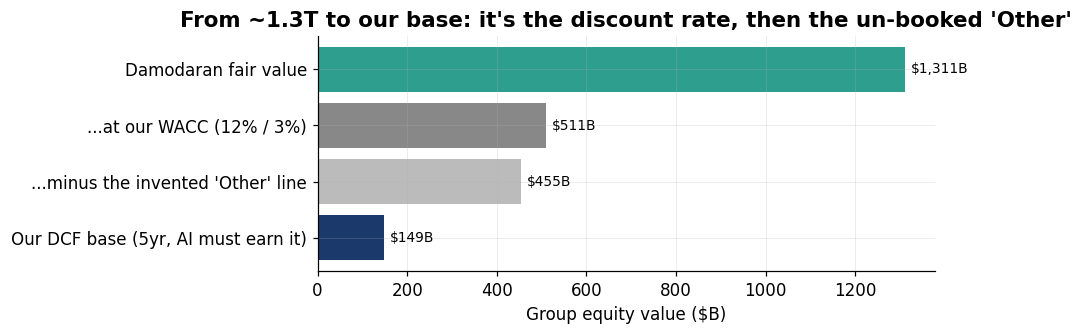

In [6]:
# His cash flows (from the "Stories to Numbers" tab), $M. We re-discount these unchanged.
his_fcff = [-7229.2, -5767.5, 2.2, 8479.3, 15261.3, 22392.3, 39350.0, 61410.7, 84678.5, 105536.9]
his_term_fcf = 87328.5
his_debt, his_cash_ipo = 22896.0, 99747.0          # his balance-sheet bridge (incl. $75B IPO proceeds)

def op_assets(wacc, g):
    pv_exp = sum(cf / (1 + wacc)**(i + 1) for i, cf in enumerate(his_fcff))
    pv_tv  = (his_term_fcf / (wacc - g)) / (1 + wacc)**10
    return pv_exp + pv_tv

print(f"Terminal multiple:  his 1/(0.0825-0.0456) = {1/(0.0825-0.0456):4.1f}x   "
      f"ours 1/(0.12-0.03) = {1/(0.12-0.03):4.1f}x")

his_equity   = op_assets(0.0825, 0.0456) - his_debt + his_cash_ipo      # ~$1.30T (reproduces his sheet)
ours_rates   = op_assets(0.12,   0.03)   - his_debt + his_cash_ipo      # his story, OUR discount rate
# His "Other" line, valued at OUR rate: $30B terminal EBIT -> after-tax, capitalised at 11x, PV'd 10yr
other_fcff   = 30000 * (1 - 0.25) * (1 - 0.0456/0.15)
other_value  = (other_fcff / (0.12 - 0.03)) / (1.12)**10
no_other     = ours_rates - other_value
base         = d["base"]                                               # our DCF base equity ($M)

bridge = [("Damodaran fair value",              his_equity),
          ("...at our WACC (12% / 3%)",          ours_rates),
          ("...minus the invented 'Other' line", no_other),
          ("Our DCF base (5yr, AI must earn it)", base)]

print("\nBridge (equity, $B):")
prev = None
for label, v in bridge:
    delta = "" if prev is None else f"   ({(v-prev)/1000:+,.0f}B)"
    print(f"  {label:38s} ${v/1000:6.0f}B  ({b2ps(v/1000):6.2f}/sh){delta}")
    prev = v

fig, ax = plt.subplots(figsize=(9, 3.2))
labels = [l for l, _ in bridge]
vals   = [v/1000 for _, v in bridge]
ax.barh(range(len(vals)), vals, color=[COL.get("Connectivity"), "#888", "#bbb", COL.get("Space")])
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels); ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v + 12, i, f"${v:,.0f}B", va="center", fontsize=9)
ax.set_xlabel("Group equity value ($B)")
ax.set_title("From ~1.3T to our base: it's the discount rate, then the un-booked 'Other'")
charts.save(fig, "damodaran_bridge")
plt.show()

## The field — assembled

Three method bars (DCF solid = S-1; SOTP and real-option hatched = external), the probability/midpoint as a
diamond, the convergence zone where **all three overlap** shaded, and the private mark as a dashed line. The
top axis converts equity \$B to \$/share (÷ 12,520M pro-forma).

Read it the way it's meant to be read: the bars **agree** on a broad ~\$160–240B middle (Starlink does the
heavy lifting in every method), and **disagree** only on how far above that the AI option carries you. The
private mark sits at the top of the field — it is a *bull-and-AI-works* price, not a fundamentals price.

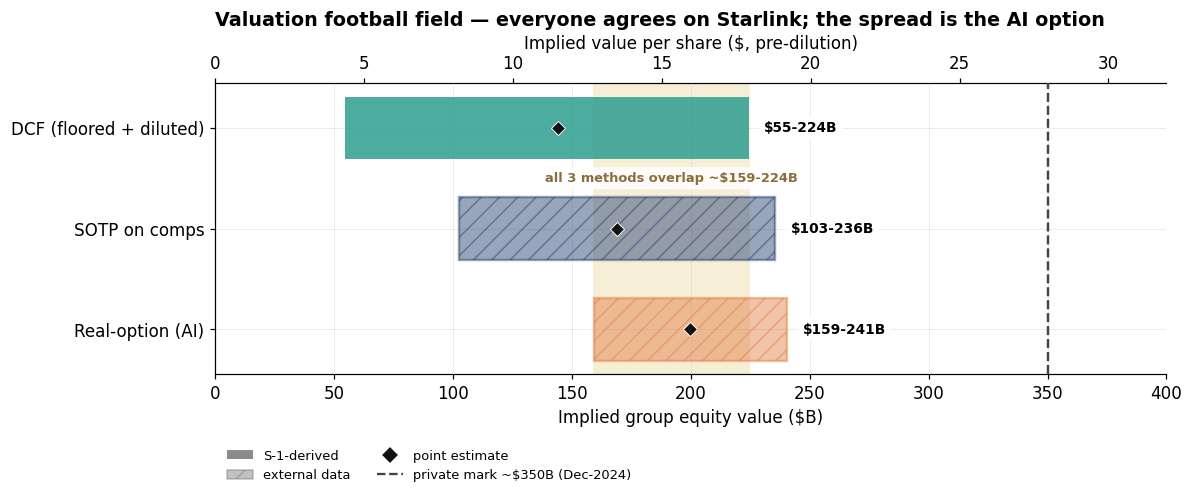

In [7]:
bars = ff[ff.method != "Private mark (Dec-2024)"].reset_index(drop=True)
pm = val.private_mark_anchor_b()
method_colors = {"DCF (floored + diluted)": COL["Connectivity"],
                 "SOTP on comps":           COL["Space"],
                 "Real-option (AI)":        COL["AI"]}
cols = [method_colors[m] for m in bars.method]

fig, ax = plt.subplots(figsize=(11, 4.8))
charts.hbar_range(bars, ax=ax, colors=cols, point="point")

# convergence zone = where all three bars overlap
zlo, zhi = bars.low.max(), bars.high.min()
ax.axvspan(zlo, zhi, color="#f4e7c8", alpha=0.7, zorder=0)
charts.annotate_clear(ax, f"all 3 methods overlap ~${zlo:.0f}-{zhi:.0f}B", ((zlo+zhi)/2, 0.5),
            ha="center", va="center", fontsize=8.5, color="#8a6d3b", fontweight="bold")

# private-mark reference line
ax.axvline(pm, color="#444", ls="--", lw=1.6, zorder=4)


# range labels (stagger if near private-mark line)
for i, r in bars.iterrows():
    dx = 10 if abs(r.high - pm) > 25 else -72
    ha = "left" if dx > 0 else "right"
    charts.annotate_clear(ax, f"${r.low:.0f}-{r.high:.0f}B", (r.high, i),
                          xytext=(dx, 0), textcoords="offset points",
                          va="center", ha=ha, fontsize=9, fontweight="bold")

ax.set_xlabel("Implied group equity value ($B)")
ax.set_xlim(0, 400)
sax = ax.secondary_xaxis("top", functions=(lambda b: b2ps(b), lambda p: p*SHARES/1000.0))
sax.set_xlabel("Implied value per share ($, pre-dilution)")
ax.set_title("Valuation football field — everyone agrees on Starlink; the spread is the AI option",
             loc="left", fontsize=12.5)
leg = [Patch(facecolor="#777", alpha=0.85, label="S-1-derived"),
       Patch(facecolor="#777", alpha=0.45, hatch="//", edgecolor="#777", label="external data"),
       Line2D([0], [0], marker="D", color="w", markerfacecolor="#111", markersize=8, label="point estimate"),
       Line2D([0], [0], color="#444", ls="--", label=f"private mark ~${pm:.0f}B (Dec-2024)")]
ax.legend(handles=leg,
          fontsize=8.5, loc="upper left", bbox_to_anchor=(0, -0.22), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.22)
charts.finish(fig); charts.save(fig, "valuation_field", layout=False); plt.show()

## Reverse-DCF — what the private mark is actually assuming

A football field begs the question the other way round: *what would you have to believe* for the \$350B mark
to be right? Not a bar — a diagnostic. Back the mark into an implied EV and divide by FY2025 revenue.

In [8]:
rev_fy25 = 18674.0  # FY2025 consolidated revenue ($M), S-1
ev_at_mark = pm*1000 + val.net_debt_m()      # $M
d = val.dcf_range(A)
print(f"Reverse-DCF on the ${pm:.0f}B private mark:")
print(f"  implied EV          = ${ev_at_mark/1000:.0f}B")
print(f"  / FY2025 revenue    = {ev_at_mark/rev_fy25:.1f}x   (revenue ${rev_fy25/1000:.1f}B)")
print(f"  our DCF bull equity = ${d['bull']/1000:.0f}B  ->  the mark is, essentially, the bull case")

Reverse-DCF on the $350B private mark:
  implied EV          = $364B
  / FY2025 revenue    = 19.5x   (revenue $18.7B)
  our DCF bull equity = $224B  ->  the mark is, essentially, the bull case


## Synthesis — where the methods agree, and where they don'\''t

**They agree on the floor and the middle.** Strip out the AI optionality and three independent engines —
discounted cash flow, peer multiples, and a Starlink+Space DCF — land in a broad **~$160–240B** band. That
convergence is real because it is mostly the *same asset*: Starlink, valued three different ways, keeps
coming out around $60–115B+ of equity (the DCF bull'\''s Connectivity is now the §7.7 **flywheel** — ARPU↓$38
/ ~64M subs / ~58% computed margin), and Space adds a modest, defensible launch-franchise layer. This is
the part of the number we'\''d defend in a fight.

**They disagree on AI, and only on AI.**
- **DCF** floors AI at $0 (it can'\''t cover its own refresh in bear/base) — so AI *subtracts* in the
  near term and contributes nothing in terminal unless the Bull frontier clears.
- **SOTP on comps** gives AI a disciplined $16–54B on neocloud revenue multiples.
- **The real-option** bar prices the *upside* the DCF discards — a `P × payoff` that, at believer settings,
  adds the most of any single input.
- **The private mark** (~$230B for xAI *alone*; ~$350B for the whole company) sits **above every method'\''s
  high** — even the real-option bar tops out near ~$240B. The market is paying for AI at a level no
  cash-flow or revenue-multiple method supports — i.e. it is buying the option, in size, today.

**So the football field'\''s verdict is a sentence:** on the S-1'\''s own numbers the company is worth ~$160–240B;
the ~$350B private mark prices *above even our most internally-consistent bull*, and the entire distance
from the convergence zone to the mark is the value of an AI bet the cash flows do not yet justify. That is
not a knock — it is the trade. A buyer at the mark is underwriting the AI option; a buyer at the convergence
zone is underwriting Starlink and getting the option for free.

**What we did not force.** No assumption was tuned to manufacture overlap; the bars disagree exactly where
the business is genuinely uncertain. **Deferred** (honestly flagged): the **replacement / asset floor**
(`valuation.replacement_value()` is a stub — needs defensible per-satellite + launch + spectrum costs),
cash taxes, and a tighter `P`/payoff calibration for the AI option. **External-data caveat:** comps and
marks are not S-1 facts; they are date-stamped, reliability-flagged, and quarantined in `csv/comps.csv` /
`csv/market_marks.csv`, and private valuations move fast — re-date them before the report ships.

> **Going further — the $1T question.** The hype around this IPO reaches into the trillions. For a standalone reverse-engineering of *what you must believe* to justify a $1T+ valuation (it is almost entirely an AI-segment bet), see **`notebooks/trillion.ipynb`** (engine: `analysis/trillion.py`).